Наконец настало время собрать всё воедино!

<h1>Импорт библиотек</h1>

In [1]:
import math
import pandas as pd
from collections import defaultdict
from tqdm.notebook import tqdm
import random
import cv2
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from torchvision import datasets
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.utils import draw_bounding_boxes
from PIL import Image


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from utils import align_face


device = 'cuda' if torch.cuda.is_available() else 'cpu'

<h1>Детектор</h1>

In [2]:
# !pip install facenet-pytorch

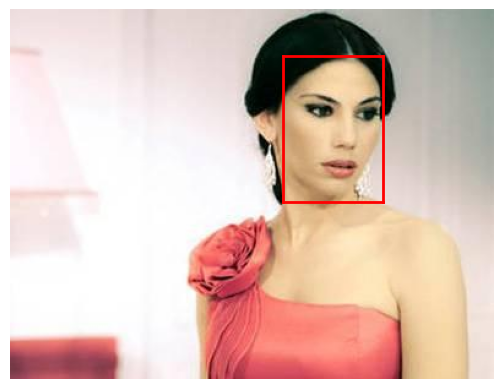

In [3]:
from facenet_pytorch import MTCNN
import matplotlib.patches as patches


detector = MTCNN(keep_all=True, device=device)
image = Image.open('../data/celeba/img/000057.jpg')
boxes, _ = detector.detect(image)

def plot_bbox(bbox):
    x1, y1, x2, y2 = bbox
    plt.plot([x1, x2], [y1, y1], color='red', linewidth=2)
    plt.plot([x1, x2,], [y2, y2], color='red', linewidth=2)
    plt.plot([x1, x1,], [y1, y2], color='red', linewidth=2)
    plt.plot([x2, x2,], [y1, y2], color='red', linewidth=2)
    plt.axis('off')
    
plt.imshow(image)
plot_bbox(boxes[0])

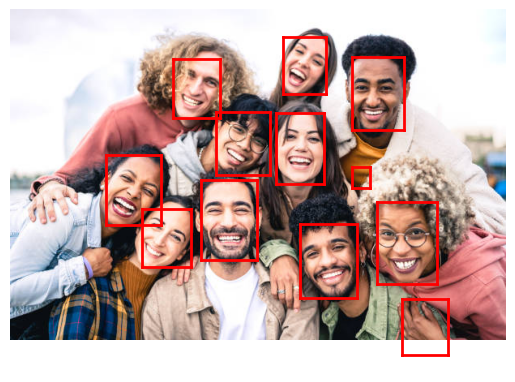

In [4]:
image = Image.open('../data/test_group3.jpg')
boxes, _ = detector.detect(image)

def plot_bbox(bbox):
    x1, y1, x2, y2 = bbox
    plt.plot([x1, x2], [y1, y1], color='red', linewidth=2)
    plt.plot([x1, x2,], [y2, y2], color='red', linewidth=2)
    plt.plot([x1, x1,], [y1, y2], color='red', linewidth=2)
    plt.plot([x2, x2,], [y1, y2], color='red', linewidth=2)
    plt.axis('off')

plt.imshow(image)
for bbox in boxes:
    plot_bbox(bbox)

In [5]:
def crop_image(image, bbox):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    x1, y1, x2, y2 = bbox
    w, h = x2 - x1, y2 - y1
    image = image.crop((x1 - 0.3 * w, y1 - 0.3 * h, x2 + 0.3 * w, y2 + 0.3 * h))
    image = transform(image)

    return image

<h1>Выравнивание</h1>

In [7]:
shg_model = torch.jit.load("../notebooks/models/shg/shg_final.pt", map_location='cpu')
shg_model = shg_model.to(device)

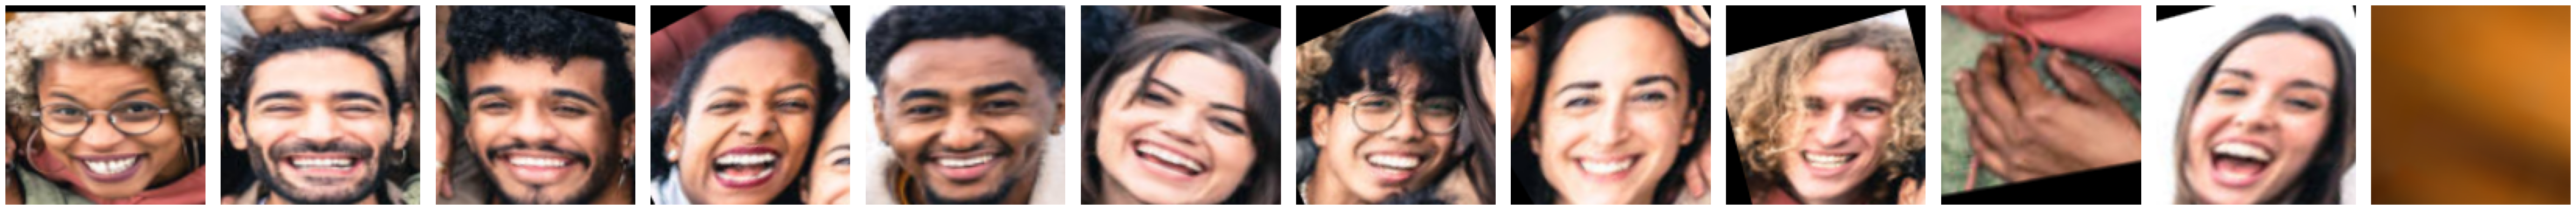

In [ ]:
fig, axes = plt.subplots(1, len(boxes), figsize=(4 * len(boxes), 4))
for i, bbox in enumerate(boxes):
    face_tensor = crop_image(image, bbox)
    face_tensor = align_face(face_tensor, shg_model)
    img_np = face_tensor 

    if len(boxes) == 1:
        ax = axes
    else:
        ax = axes[i]
    ax.imshow(img_np)
    ax.axis('off')

plt.tight_layout()
plt.show()

<h1>Распознавание</h1>

In [120]:
resnet_18 = torch.jit.load('./models/resnet18_ArcFace/arc_resnet_18_jit.pt')



resnet_18.eval()

RecursiveScriptModule(
  original_name=ResNet
  (conv1): RecursiveScriptModule(original_name=Conv2d)
  (bn1): RecursiveScriptModule(original_name=BatchNorm2d)
  (relu): RecursiveScriptModule(original_name=ReLU)
  (maxpool): RecursiveScriptModule(original_name=MaxPool2d)
  (layer1): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(
      original_name=BasicBlock
      (conv1): RecursiveScriptModule(original_name=Conv2d)
      (bn1): RecursiveScriptModule(original_name=BatchNorm2d)
      (relu): RecursiveScriptModule(original_name=ReLU)
      (conv2): RecursiveScriptModule(original_name=Conv2d)
      (bn2): RecursiveScriptModule(original_name=BatchNorm2d)
    )
    (1): RecursiveScriptModule(
      original_name=BasicBlock
      (conv1): RecursiveScriptModule(original_name=Conv2d)
      (bn1): RecursiveScriptModule(original_name=BatchNorm2d)
      (relu): RecursiveScriptModule(original_name=ReLU)
      (conv2): RecursiveScriptModule(original_name=Conv2d)

<h1>ИТОГОВЫЙ ПАЙПЛАЙН</h1>

In [121]:
# def recognize_faces(image):
#     resnet_transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])
#     boxes, _ = detector.detect(image)
#     aligned_faces = []
#     for bbox in (boxes):
#         face_tensor = crop_image(image, bbox)
#         aligned = align_face(face_tensor, shg_model)
#         aligned_faces.append(aligned)
    
#     embeddings = []
#     resnet_18.eval()

#     for face in aligned_faces:
#         face = face.unsqueeze(0).to(next(resnet_18.parameters()).device)
#         with torch.no_grad():
#             embed = resnet_18(face)
#             embeddings.append(embed)
#     return embeddings

In [122]:
from PIL import Image

def recognize_faces(image):
    resnet_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    boxes, _ = detector.detect(image)
    embeddings = []

    for bbox in boxes:
        face_tensor = crop_image(image, bbox)  # tensor с нормализацией для align_face
        aligned_np = align_face(face_tensor, shg_model)  # numpy uint8 (128,128,3)

        # Convert numpy array (H,W,C) to PIL Image
        aligned_pil = Image.fromarray(aligned_np)

        # Применяем трансформацию для resnet
        face_for_resnet = resnet_transform(aligned_pil).to(device)  # tensor [3,224,224]

        # Добавляем batch dimension и подаём в модель
        face_for_resnet = face_for_resnet.unsqueeze(0)

        resnet_18.eval()
        with torch.no_grad():
            emb = resnet_18(face_for_resnet)
            emb = F.normalize(emb, dim=1)
            embeddings.append(emb.squeeze(0).cpu())

    return embeddings


In [123]:
image = Image.open('../data/test_group3.jpg')

In [124]:
embeddings = recognize_faces(image)

In [125]:
len(embeddings)

12

<h1>Тестирование с разными фото</h1>

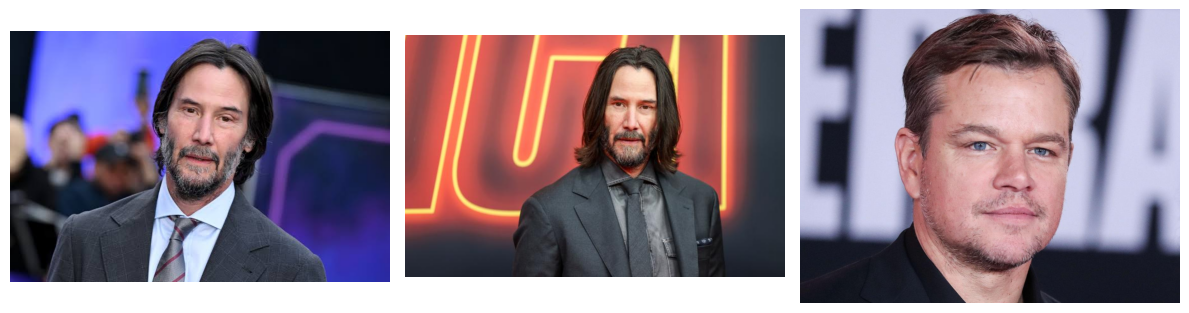

In [136]:
image1 = Image.open('../data/test_person_1_1.jpg')
image2 = Image.open('../data/test_person_1_2.jpg')
image3 = Image.open('../data/test_person_2_1.jpg')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
images = [image1, image2, image3]

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
embs1 = recognize_faces(image1)
embs2 = recognize_faces(image2)
embs3 = recognize_faces(image3)
emb1 = embs1[0]
emb2 = embs2[0]
emb3 = embs3[0]

In [142]:
sim_same = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0), dim=1).item()
sim_diff = F.cosine_similarity(emb1.unsqueeze(0), emb3.unsqueeze(0), dim=1).item()


print(f"Similarity same person = {sim_same:.3f}")
print(f"Similarity different person = {sim_diff:.3f}")

Similarity same person = 0.892
Similarity different person = 0.574


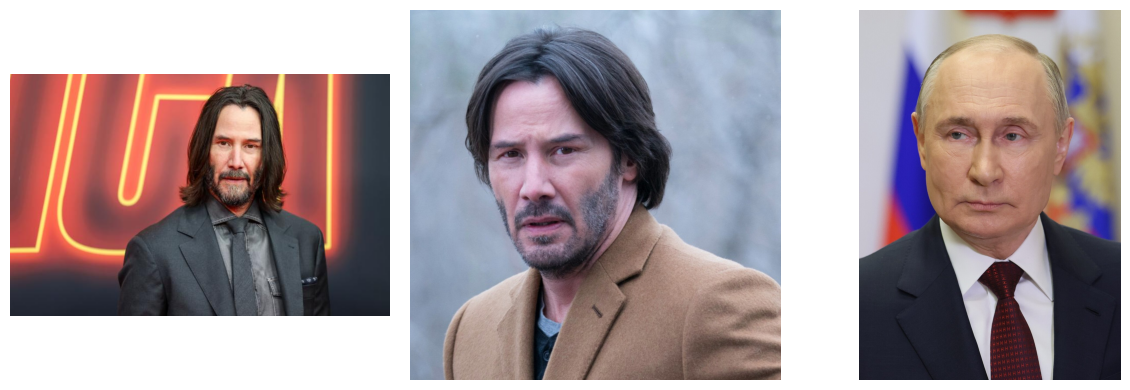

In [143]:
image1 = Image.open('../data/test_person_1_2.jpg')
image2 = Image.open('../data/test_person_1_3.jpg')
image3 = Image.open('../data/test_person_3_1.jpg')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
images = [image1, image2, image3]

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [144]:
embs1 = recognize_faces(image1)
embs2 = recognize_faces(image2)
embs3 = recognize_faces(image3)
emb1 = embs1[0]
emb2 = embs2[0]
emb3 = embs3[0]

sim_same = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0), dim=1).item()
sim_diff = F.cosine_similarity(emb1.unsqueeze(0), emb3.unsqueeze(0), dim=1).item()


print(f"Similarity same person = {sim_same:.3f}")
print(f"Similarity different person = {sim_diff:.3f}")

Similarity same person = 0.794
Similarity different person = 0.586


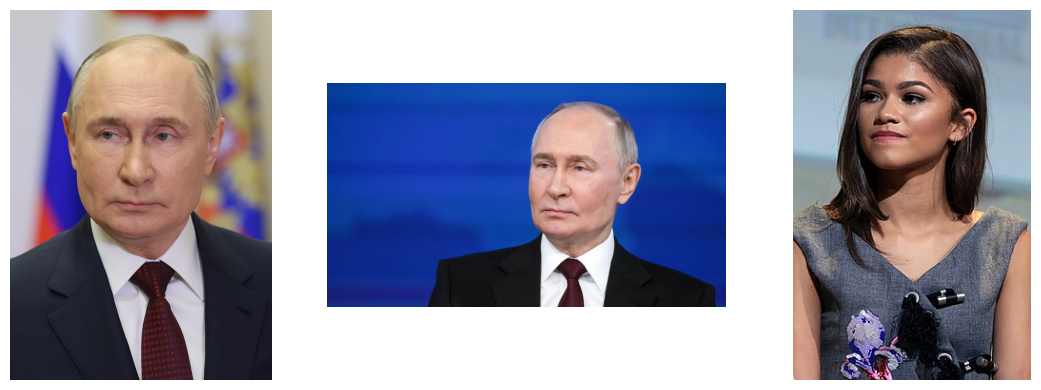

In [156]:
image1 = Image.open('../data/test_person_3_1.jpg')
image2 = Image.open('../data/test_person_3_2.jpg')
image3 = Image.open('../data/test_person_4_1.jpg')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
images = [image1, image2, image3]

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [157]:
embs1 = recognize_faces(image1)
embs2 = recognize_faces(image2)
embs3 = recognize_faces(image3)
emb1 = embs1[0]
emb2 = embs2[0]
emb3 = embs3[0]

sim_same = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0), dim=1).item()
sim_diff = F.cosine_similarity(emb1.unsqueeze(0), emb3.unsqueeze(0), dim=1).item()


print(f"Similarity same person = {sim_same:.3f}")
print(f"Similarity different person = {sim_diff:.3f}")

Similarity same person = 0.859
Similarity different person = 0.613
